<a href="https://colab.research.google.com/github/leonardo2004/Calculo-Numerico/blob/main/Atividade%2002/Atividade02_CalcNumerico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade 2
## Leonardo Tomasela Leal - 170291
##Giovanna Maria de Siqueira Junqueira - 185218
##Guilherme Miguel Spyrides Leite Ferro - 176466

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


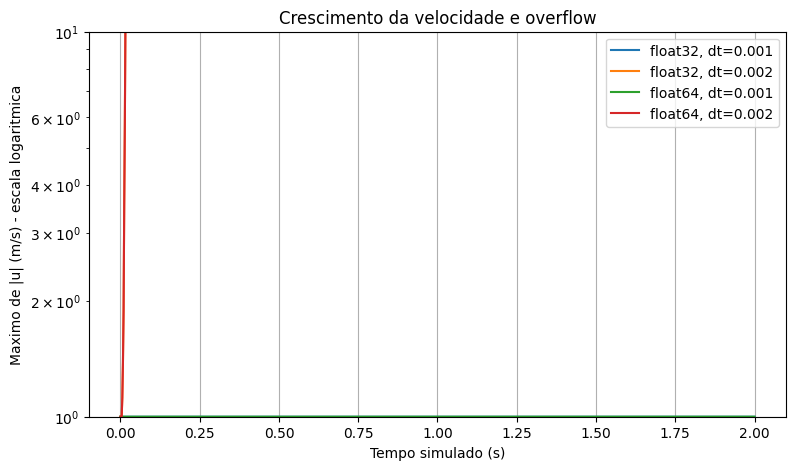

In [1]:
import numpy as np
import matplotlib.pyplot as plt



def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    global H
    H = 0.01
    global nu
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}



for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

* Caso A: ∆t = 0,001 s, com r = 0,4;
* Caso B: ∆t = 0,002 s, com r = 0,8;

# item 1

In [2]:
a_delta_t = 0.001
a_r = 0.4
b_delta_t = 0.002
b_r = 0.8
v = 10e-4

dy = H / (2000 - 1)
dt_max = dy**2/(2*v)

print(f"dt máximo: {dt_max} ; dy: {dy} ; r_a: {a_r} ; r_b: {b_r}")
print(f"Estável, {a_delta_t} <= {dt_max} e {a_r} <= {1/2}")

print(f"Instável, {b_delta_t} <= {dt_max} mas {b_r} > {1/2}")

dt máximo: 1.2512509381253909e-08 ; dy: 5.002501250625313e-06 ; r_a: 0.4 ; r_b: 0.8
Estável, 0.001 <= 1.2512509381253909e-08 e 0.4 <= 0.5
Instável, 0.002 <= 1.2512509381253909e-08 mas 0.8 > 0.5


Item 2


Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
----------------------------------------
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


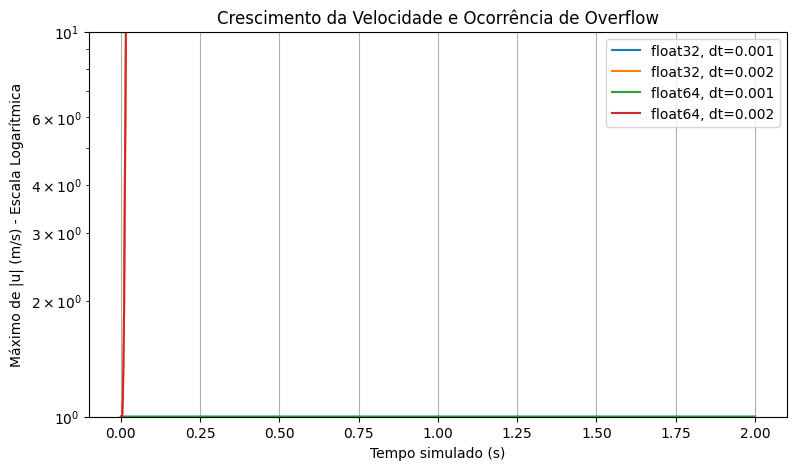

In [3]:
print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)
print("-" * 40)

resultados = {}
tipos_dados = (np.float32, np.float64)
passos_tempo = (0.001, 0.002)

for tipo in tipos_dados:
    for dt in passos_tempo:
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))
for nome, resultado in resultados.items():
    plt.semilogy(resultado["tempos"], resultado["maximos"], label=nome)

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Máximo de |u| (m/s) - Escala Logarítmica")
plt.title("Crescimento da Velocidade e Ocorrência de Overflow")
plt.grid(True)
plt.legend()
plt.show()

Detecção de Overflow (Tabela de Resultados)

Com base na execução do código acima, os resultados obtidos foram:

| Tipo Numérico | Passo de Tempo ($\Delta t$) | Valor de $r$ | Ocorrência de Overflow | Iteração da Falha |
| :---: | :---: | :---: | :---: | :---: |
| float32 | 0.001 | 0.4 | Não | - |
| float32 | 0.002 | 0.8 | Sim | 156 |
| float64 | 0.001 | 0.4 | Não | - |
| float64 | 0.002 | 0.8 | Sim | 1198 |

#Item 3

O crescimento no caso instável não representa o comportamento físico esperado porque o crescimento contínuo e exponencial observado não tem nenhum sentido físico. O fluido é movido pelo arrasto viscoso gerado por uma placa que se move a  $U = 1$ m/s.

Fisicamente, a velocidade em qualquer ponto do fluido nunca poderia ultrapassar a velocidade máxima imposta pelo contorno ($1$ m/s). Os valores indo para a casa dos $10^{38}$ ou $10^{300}$ são erros numéricos que são amplificados interativamente devido ao fator de ponderação negativo na equação ($r > 0.5$)

#Item 4

A mudança do tipo de variável de `float32` para `float64` não elimina a instabilidade.
A instabilidade é um problema matematico gerado pelo passo de tempo inadequado. A única diferença é que o `float64` suporta representar números significativamente maiores (até $\approx 1.8 \times 10^{308}$) do que o `float32` (até $\approx 3.4 \times 10^{38}$).
Por isso, a simulação em `float64` apresenta mais iterações para finalmente "estourar" a capacidade de memória e acusar o erro de *overflow*, mas vale ressaltar que os dados já estavam incorretos e sem sentida físico já nos primeiros instantes.

#Item 5

Ao alterar a malha para $41$ pontos, a geometria e os limites teóricos são recalculados. Desta forma:
$$ \Delta y_{novo} = \frac{0.01}{41 - 1} = \frac{0.01}{40} = 0.00025 \text{ m} $$

Assim, o novo limite máximo de tempo se torna muito mais restrito.Como demonstrado abaixo.

$$ \Delta t_{max, novo} = \frac{(0.00025)^2}{2 \times 10^{-4}} = \frac{6.25 \times 10^{-8}}{2 \times 10^{-4}} = 0.0003125 \text{ s} $$

Já se mantivermos o passo antigo de  $\Delta t = 0.001$ s, o novo $r$ seria:
$$ r = \frac{10^{-4} \times 0.001}{(0.00025)^2} = 1.6 $$
Como $r > 0.5$, o método irá falhar.

Por fim, para que seja estável, precisamos de um $\Delta t \le 0.0003125$ s. Para isso, escolheremos $\Delta t = 0.0002$ s.

In [4]:
print("Teste 1: 41 pontos e dt = 0.001 (Falha)")
resultado_falho_41 = simular(dt=0.001, tipo=np.float64, passos=2000, pontos=41)

print("\n Teste 2: 41 pontos e dt = 0.0002 (Funciona, pois está abaixo do limite)")
resultado_estavel_41 = simular(dt=0.0002, tipo=np.float64, passos=10000, pontos=41)

Teste 1: 41 pontos e dt = 0.001 (Falha)
dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract

 Teste 2: 41 pontos e dt = 0.0002 (Funciona, pois está abaixo do limite)
dt=0.0002, float64: 10000 passos sem overflow.


#Item 6

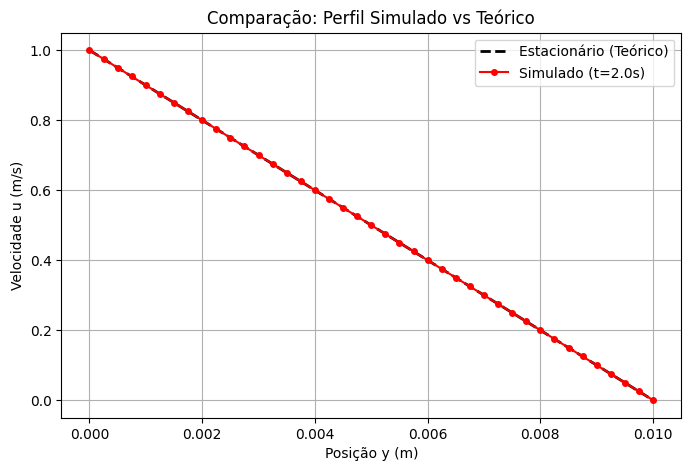

Diferença máxima (Erro E_infinito): 0.00000000 m/s


In [5]:
h_placa = 0.01
vel_placa = 1.0

y_vel = resultado_estavel_41["y"]
u_simulado = resultado_estavel_41["u"]
u_teorico = vel_placa * (1 - (y_vel / h_placa))

erro_maximo = np.max(np.abs(u_simulado - u_teorico))

plt.figure(figsize=(8, 5))
plt.plot(y_vel, u_teorico, 'k--', linewidth=2, label="Estacionário (Teórico)")
plt.plot(y_vel, u_simulado, 'r-', marker='o', markersize=4, label="Simulado (t=2.0s)")

plt.xlabel("Posição y (m)")
plt.ylabel("Velocidade u (m/s)")
plt.title("Comparação: Perfil Simulado vs Teórico")
plt.grid(True)
plt.legend()
plt.show()

print(f"Diferença máxima (Erro E_infinito): {erro_maximo:.8f} m/s")

A diferença máxima calculada ($E_\infty$) entre a simulação e a teoria é um valor minúsculo. Isso comprova que a simulação está correta. O tempo total simulado ($10000$ passos $\times 0.0002$ s $= 2.0$ segundos) foi mais que suficiente para o fluido atingir o "regime estacionário", que é quando o movimento da placa inferior se propaga por todo o fluido, criando assim, um perfil de velocidade perfeitamente linear.


#Item 7

A relação de malha e de tempo se dá pela dependência quadrática entre o refinamento da malha espacial  ($\Delta y$) e o limite de tempo ($\Delta t$) para métodos explícitos. Ao reduzir o $\Delta y$ pela metade força a redução do $\Delta t$ em quatro vezes para manter a estabilidade.

Já a relação entre a instabilidade e o Overflow ocorre por a instabilidade ser causada pelo cálculo de ponderações negativas levando a propagação de pertubações, enquanto o overflow é a consequência final, no qual as pertubações crescem tanto que ultrapassam a memória do computador.

Para a correção, a alteração que corrige a causa da falha na simulação é o respeito a condição de estabilidade Courant-Friedrichs-Lewy (ou o critério difusivo) do método, o que garante que o parâmetro $r$ seja inferior ou igual a $0.5$ ($\Delta t \le \Delta y^2 / 2\nu$). Aumentar a precisão para `float64` mascara o problema por alguns instantes, mas não conserta a parte física.